In [1]:
import torch
from transformers import AutoModelForCausalLM

from janus.models import MultiModalityCausalLM, VLChatProcessor
import numpy as np
import os, time
import PIL.Image

# for probe
from probes.attn_probe_runtime import attach_layer_indices, enable_attention_probe, set_probe_callback, TokenStat
# from probes.layer_hooks import register_lasttoken_hooks
import torch
import torch.nn.functional as F
from datetime import datetime

torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

# specify the path to the model
# model_path = "deepseek-ai/Janus-1.3B"
model_path = "/home/vlgd/Models/Janus-Pro-1B/"
# vl_chat_processor: VLChatProcessor = VLChatProcessor.from_pretrained(model_path)
# tokenizer = vl_chat_processor.tokenizer

vl_gpt: MultiModalityCausalLM = AutoModelForCausalLM.from_pretrained(
    model_path, trust_remote_code=True
)

/home/vlgd/anaconda3/envs/gsdpy310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python version is above 3.10, patching the collections module.


/home/vlgd/anaconda3/envs/gsdpy310/lib/python3.10/site-packages/transformers/models/auto/image_processing_auto.py:590: FutureWarning: The image_processor_class argument is deprecated and will be removed in v4.42. Please use `slow_image_processor_class`, or `fast_image_processor_class` instead
  warnings.warn(


In [2]:
embeddings = vl_gpt.gen_vision_model.quantize.embedding.weight.detach().cpu()
print(embeddings.shape)
print(embeddings.mean(axis=0), embeddings.std(axis=0))

torch.Size([16384, 8])
tensor([-0.0177,  0.0298, -0.0025,  0.0141, -0.0090,  0.0054,  0.0150,  0.0394]) tensor([0.3587, 0.3665, 0.3571, 0.3541, 0.3668, 0.3587, 0.3833, 0.3804])


In [10]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

E = embeddings.detach().cpu().numpy()
N, D = E.shape
print(E.shape)

(16384, 8)


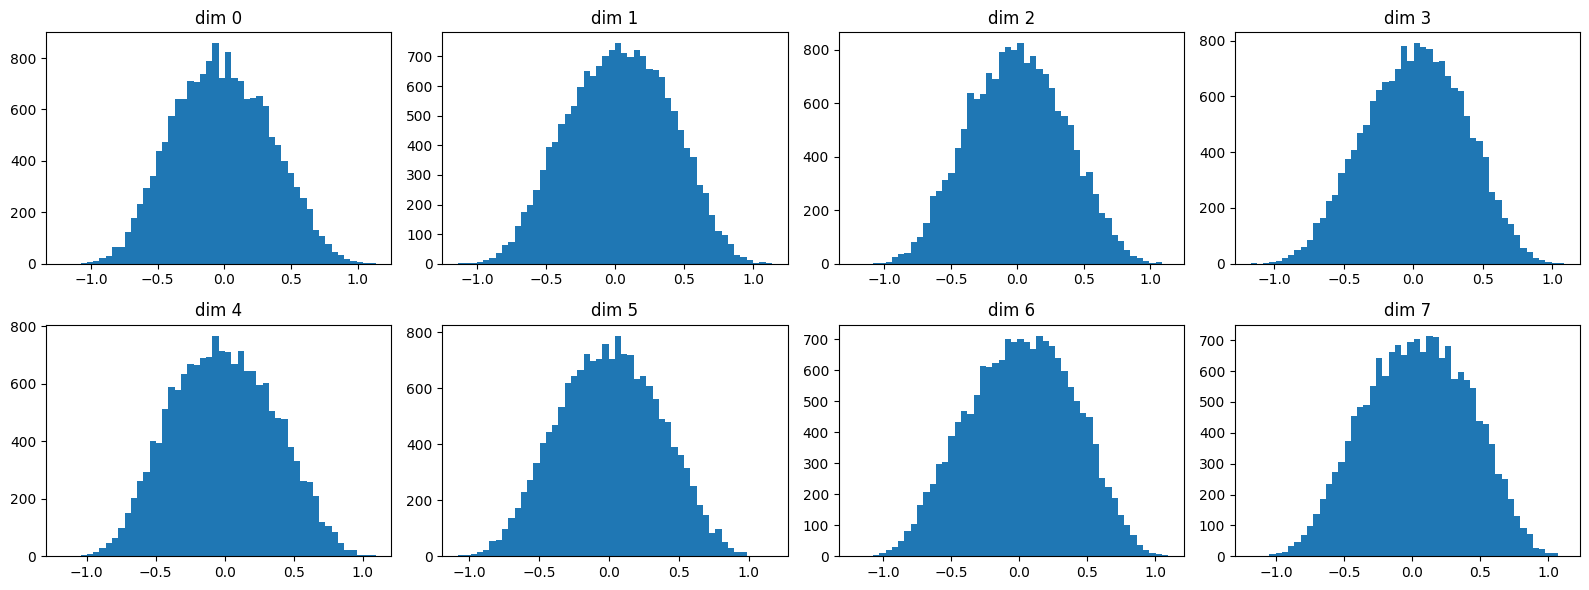

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()
for i in range(D):
    axes[i].hist(E[:, i], bins=50)
    axes[i].set_title(f"dim {i}")
plt.tight_layout()
plt.show()

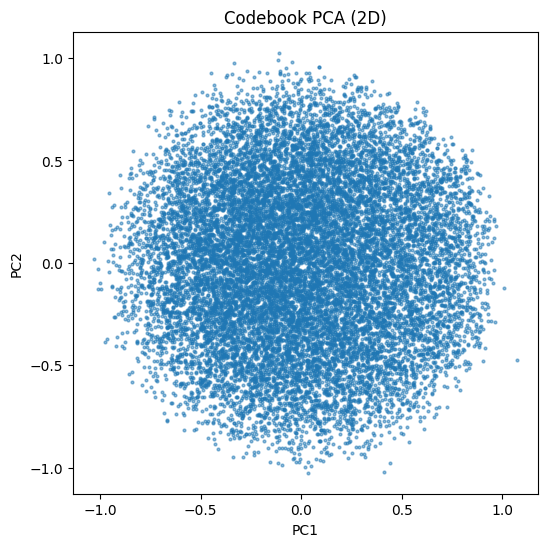

In [11]:
pca = PCA(n_components=2)
E_pca = pca.fit_transform(E)  # [16384, 2]

plt.figure(figsize=(6, 6))
plt.scatter(E_pca[:, 0], E_pca[:, 1], s=4, alpha=0.5)
plt.title("Codebook PCA (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 16384 samples in 0.024s...
[t-SNE] Computed neighbors for 16384 samples in 3.910s...
[t-SNE] Computed conditional probabilities for sample 1000 / 16384
[t-SNE] Computed conditional probabilities for sample 2000 / 16384
[t-SNE] Computed conditional probabilities for sample 3000 / 16384
[t-SNE] Computed conditional probabilities for sample 4000 / 16384
[t-SNE] Computed conditional probabilities for sample 5000 / 16384
[t-SNE] Computed conditional probabilities for sample 6000 / 16384
[t-SNE] Computed conditional probabilities for sample 7000 / 16384
[t-SNE] Computed conditional probabilities for sample 8000 / 16384
[t-SNE] Computed conditional probabilities for sample 9000 / 16384
[t-SNE] Computed conditional probabilities for sample 10000 / 16384
[t-SNE] Computed conditional probabilities for sample 11000 / 16384
[t-SNE] Computed conditional probabilities for sample 12000 / 16384
[t-SNE] Computed conditional probabilities for sam

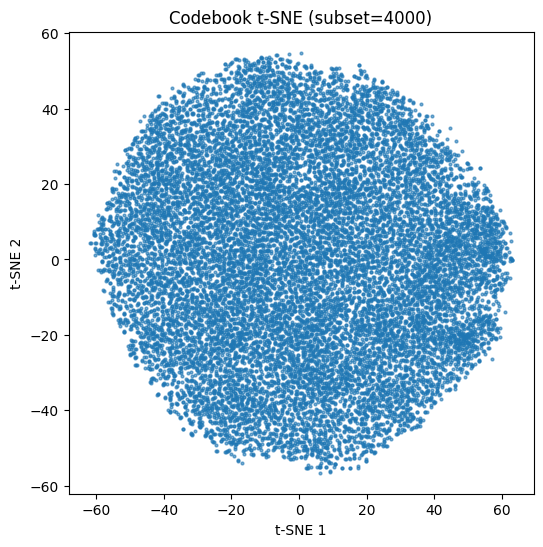

In [12]:
subset = 4000  # 可以调小/调大
idx = np.random.choice(N, size=subset, replace=False)
E_sub = E

tsne = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    max_iter=1000,
    verbose=1,
)
E_tsne = tsne.fit_transform(E_sub)  # [subset, 2]

plt.figure(figsize=(6, 6))
plt.scatter(E_tsne[:, 0], E_tsne[:, 1], s=4, alpha=0.6)
plt.title(f"Codebook t-SNE (subset={subset})")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import os

probe_dir = "probe_runtime/"

bs_prob = np.load(os.path.join(probe_dir, "baseline_prob.npy"))
pl_prob = np.load(os.path.join(probe_dir, "row_parallel_prob.npy"))
bs_token = np.load(os.path.join(probe_dir, "baseline_token.npy"))
pl_token = np.load(os.path.join(probe_dir, "row_parallel_token.npy"))

H, W = 24, 24 
eps = 1e-12
B, N, V = bs_prob.shape


In [14]:
bs_flat = bs_token.reshape(-1)
pl_flat = pl_token.reshape(-1)
same_mask = (bs_flat == pl_flat)
diff_mask = ~same_mask

print("total positions:", bs_flat.shape[0])
print("same:", same_mask.sum(), "diff:", diff_mask.sum())
print(bs_token.shape, bs_flat.shape)

total positions: 2880
same: 122 diff: 2758
(5, 576) (2880,)


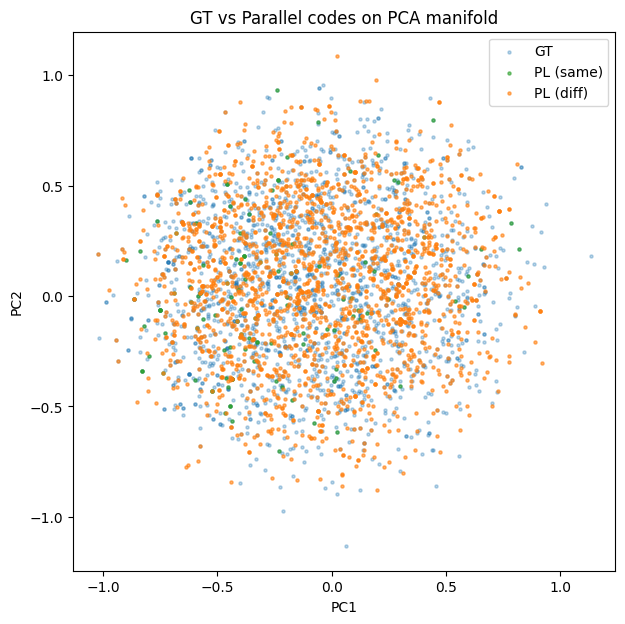

In [15]:
num_sample = 4000
idx_all = np.arange(bs_flat.shape[0])

idx_same = idx_all[same_mask]
idx_diff = idx_all[diff_mask]

sample_same = np.random.choice(idx_same, size=min(num_sample//2, idx_same.shape[0]), replace=False) if idx_same.size > 0 else np.array([], dtype=int)
sample_diff = np.random.choice(idx_diff, size=min(num_sample//2, idx_diff.shape[0]), replace=False) if idx_diff.size > 0 else np.array([], dtype=int)

sample_idx = np.concatenate([sample_same, sample_diff])

gt_s = bs_flat[sample_idx]
pl_s = pl_flat[sample_idx]
same_s = gt_s == pl_s

gt_pca = E_sub[gt_s]
pl_pca = E_sub[pl_s]

plt.figure(figsize=(7, 7))
plt.scatter(gt_pca[:, 0], gt_pca[:, 1], s=5, alpha=0.3, label="GT", color="C0")

plt.scatter(pl_pca[ same_s, 0], pl_pca[ same_s, 1], s=5, alpha=0.6, label="PL (same)", color="C2")
plt.scatter(pl_pca[~same_s, 0], pl_pca[~same_s, 1], s=5, alpha=0.6, label="PL (diff)", color="C1")

plt.legend()
plt.title("GT vs Parallel codes on PCA manifold")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

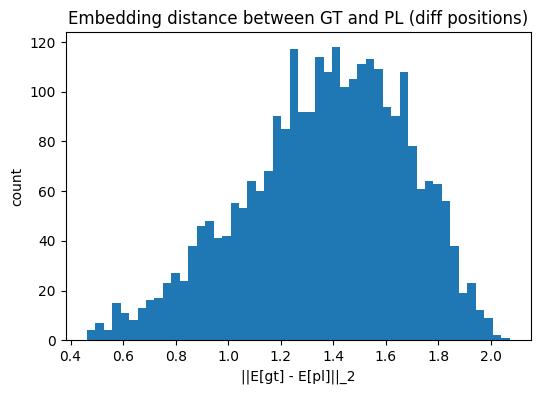

dist mean: 1.3668925 std: 0.3084982 min: 0.46178043 max: 2.0706902


In [16]:
gt_diff = bs_flat[diff_mask]
pl_diff = pl_flat[diff_mask]

E_gt = E[gt_diff]
E_pl = E[pl_diff]

dist = np.linalg.norm(E_gt - E_pl, axis=-1)  # L2 距离

plt.figure(figsize=(6, 4))
plt.hist(dist, bins=50)
plt.title("Embedding distance between GT and PL (diff positions)")
plt.xlabel("||E[gt] - E[pl]||_2")
plt.ylabel("count")
plt.show()

print("dist mean:", dist.mean(), "std:", dist.std(), "min:", dist.min(), "max:", dist.max())

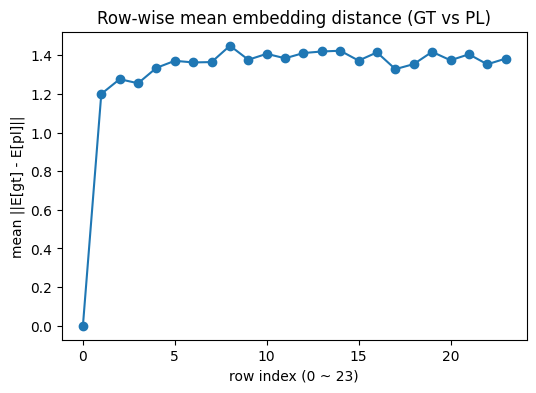

In [17]:
H = 24
W = 24
B, N = bs_token.shape

gt_2d = bs_token.reshape(B, H, W)
pl_2d = pl_token.reshape(B, H, W)

row_dist = []

for r in range(H):
    gt_r = gt_2d[:, r].reshape(-1)
    pl_r = pl_2d[:, r].reshape(-1)
    diff_r = gt_r != pl_r
    if diff_r.any():
        E_gt_r = E[gt_r[diff_r]]
        E_pl_r = E[pl_r[diff_r]]
        d_r = np.linalg.norm(E_gt_r - E_pl_r, axis=-1).mean()
    else:
        d_r = 0.0
    row_dist.append(d_r)

plt.figure(figsize=(6, 4))
plt.plot(row_dist, marker="o")
plt.title("Row-wise mean embedding distance (GT vs PL)")
plt.xlabel("row index (0 ~ 23)")
plt.ylabel("mean ||E[gt] - E[pl]||")
plt.show()

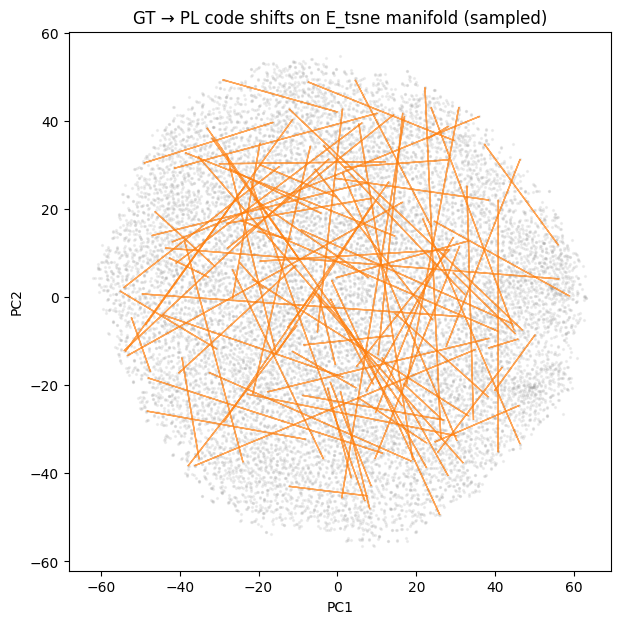

In [18]:
num_arrows = 100
idx_diff_small = np.random.choice(idx_diff, size=min(num_arrows, idx_diff.shape[0]), replace=False)

gt_a = bs_flat[idx_diff_small]
pl_a = pl_flat[idx_diff_small]

gt_p = E_tsne[gt_a]
pl_p = E_tsne[pl_a]

plt.figure(figsize=(7, 7))
plt.scatter(E_tsne[:, 0], E_tsne[:, 1], s=2, alpha=0.1, color="gray")

for i in range(gt_p.shape[0]):
    x0, y0 = gt_p[i]
    x1, y1 = pl_p[i]
    plt.arrow(x0, y0, x1 - x0, y1 - y0, head_width=0.05, alpha=0.7, color="C1", length_includes_head=True)

plt.title("GT → PL code shifts on E_tsne manifold (sampled)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


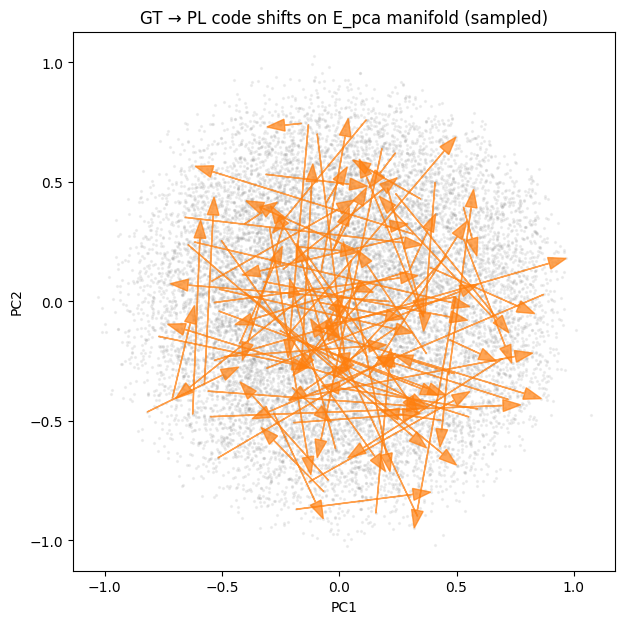

In [19]:
num_arrows = 100
idx_diff_small = np.random.choice(idx_diff, size=min(num_arrows, idx_diff.shape[0]), replace=False)

gt_a = bs_flat[idx_diff_small]
pl_a = pl_flat[idx_diff_small]

gt_p = E_pca[gt_a]
pl_p = E_pca[pl_a]

plt.figure(figsize=(7, 7))
plt.scatter(E_pca[:, 0], E_pca[:, 1], s=2, alpha=0.1, color="gray")

for i in range(gt_p.shape[0]):
    x0, y0 = gt_p[i]
    x1, y1 = pl_p[i]
    plt.arrow(x0, y0, x1 - x0, y1 - y0, head_width=0.05, alpha=0.7, color="C1", length_includes_head=True)

plt.title("GT → PL code shifts on E_pca manifold (sampled)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


In [20]:
idx_all = np.arange(bs_flat.shape[0])

num_arrows = 100
idx_all_small = np.random.choice(
    idx_all, size=min(num_arrows, idx_all.shape[0]), replace=False
)

gt_a = bs_flat[idx_all_small]
pl_a = pl_flat[idx_all_small]

print(gt_a.shape, pl_a.shape)

(100,) (100,)


In [21]:
pca_3d = PCA(n_components=3)
E_pca_3d = pca_3d.fit_transform(E) 

tsne_3d = TSNE(
    n_components=3,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    max_iter=1000,
    verbose=1,
)
E_tsne_3d = tsne_3d.fit_transform(E) 

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 16384 samples in 0.021s...
[t-SNE] Computed neighbors for 16384 samples in 3.762s...
[t-SNE] Computed conditional probabilities for sample 1000 / 16384
[t-SNE] Computed conditional probabilities for sample 2000 / 16384
[t-SNE] Computed conditional probabilities for sample 3000 / 16384
[t-SNE] Computed conditional probabilities for sample 4000 / 16384
[t-SNE] Computed conditional probabilities for sample 5000 / 16384
[t-SNE] Computed conditional probabilities for sample 6000 / 16384
[t-SNE] Computed conditional probabilities for sample 7000 / 16384
[t-SNE] Computed conditional probabilities for sample 8000 / 16384
[t-SNE] Computed conditional probabilities for sample 9000 / 16384
[t-SNE] Computed conditional probabilities for sample 10000 / 16384
[t-SNE] Computed conditional probabilities for sample 11000 / 16384
[t-SNE] Computed conditional probabilities for sample 12000 / 16384
[t-SNE] Computed conditional probabilities for sam

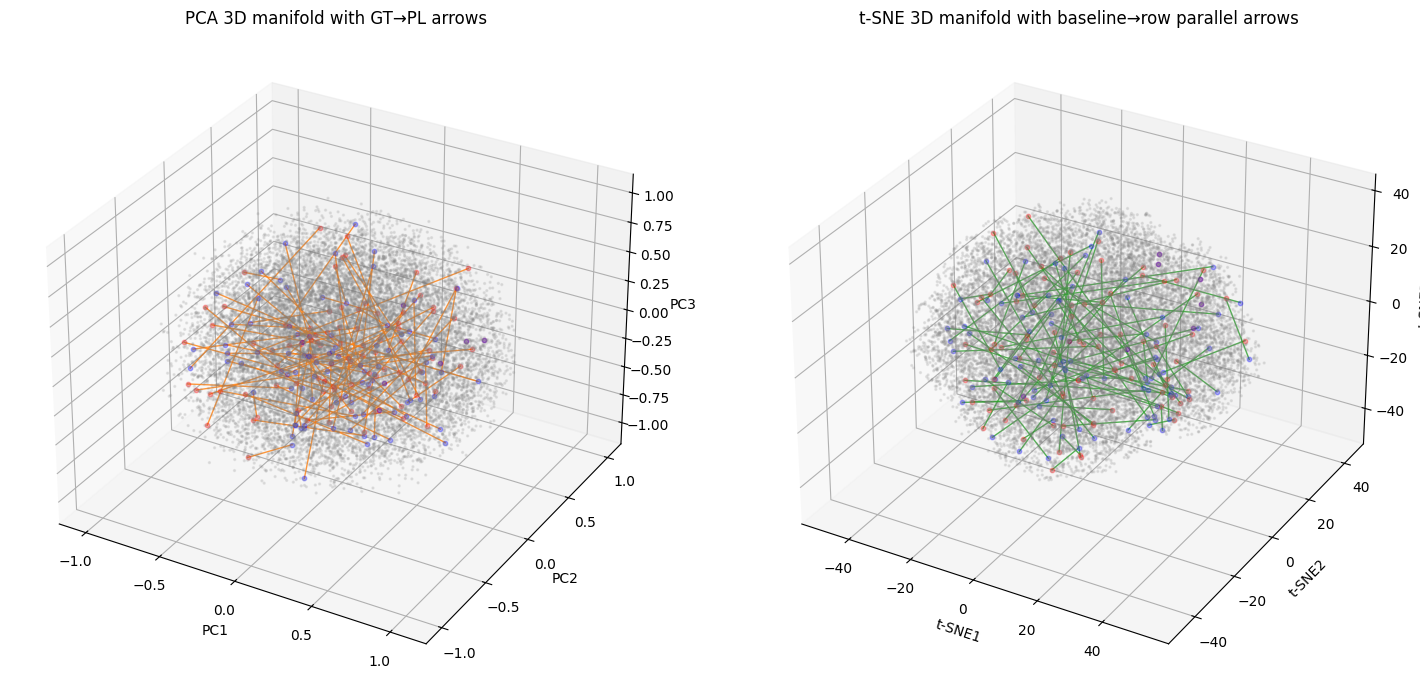

In [22]:
# fig = plt.figure(figsize=(15, 7))
fig = plt.figure(figsize=(15, 7))

ax = fig.add_subplot(121, projection='3d')
ax.scatter(E_pca_3d[:, 0], E_pca_3d[:, 1], E_pca_3d[:, 2],
           s=2, alpha=0.15, color="gray")


for x0, y0, z0, x1, y1, z1 in zip(
    E_pca_3d[gt_a][:, 0], E_pca_3d[gt_a][:, 1], E_pca_3d[gt_a][:, 2],
    E_pca_3d[pl_a][:, 0], E_pca_3d[pl_a][:, 1], E_pca_3d[pl_a][:, 2],
):
    ax.plot([x0, x1], [y0, y1], [z0, z1], color="C1", alpha=0.8, linewidth=1.0)
    ax.scatter([x0], [y0], [z0], s=10, color="red", alpha=0.3)
    ax.scatter([x1], [y1], [z1], s=10, color="blue", alpha=0.3)

ax.set_title("PCA 3D manifold with GT→PL arrows")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")


# t-SNE 3D
# fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(122, projection='3d')
ax.scatter(E_tsne_3d[:, 0], E_tsne_3d[:, 1], E_tsne_3d[:, 2],
           s=2, alpha=0.15, color="gray")

for x0, y0, z0, x1, y1, z1 in zip(
    E_tsne_3d[gt_a][:, 0], E_tsne_3d[gt_a][:, 1], E_tsne_3d[gt_a][:, 2],
    E_tsne_3d[pl_a][:, 0], E_tsne_3d[pl_a][:, 1], E_tsne_3d[pl_a][:, 2],
):
    ax.plot([x0, x1], [y0, y1], [z0, z1], color="C2", alpha=0.8, linewidth=1.0)
    ax.scatter([x0], [y0], [z0], s=10, color="red", alpha=0.3)
    ax.scatter([x1], [y1], [z1], s=10, color="blue", alpha=0.3)

ax.set_title("t-SNE 3D manifold with baseline→row parallel arrows")
ax.set_xlabel("t-SNE1")
ax.set_ylabel("t-SNE2")
ax.set_zlabel("t-SNE3")

plt.tight_layout()
# plt.show()
plt.savefig("assets/baseline_rowparallel_token_arrows.pdf", dpi=200)

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

codebook = embeddings / (np.linalg.norm(embeddings, axis=1, keepdims=True) + 1e-9)

def topn_sim_per_sample(probs, tokens, codebook, topN=5):
    B, L, V = probs.shape
    sims_list = []
    for b in range(B):
        sims = np.zeros((L, topN), dtype=np.float32)
        for t in range(L):
            p = probs[b, t]                          # [V]
            top_idx = np.argsort(-p)[:topN]          # top-N token id
            tgt_id = tokens[b, t]                    # 当前真正输出的 token
            tgt = codebook[tgt_id]                   # [D]
            cand = codebook[top_idx]                 # [N, D]
            sims[t] = cand @ tgt                     # [N] 余弦相似度
        sims_list.append(sims)
    return np.array(sims_list)

def plot_feature_per_image(feature, title, cmap="viridis"):
    assets_dir = "assets/"
    B, N = feature.shape
    vmin = np.nanmin(feature)
    vmax = np.nanmax(feature)
    norm = Normalize(vmin=vmin, vmax=vmax)
    fig, axs = plt.subplots(1, B, figsize=(4 * B, 4))
    if B == 1:
        axs = [axs]
    for b, ax in enumerate(axs):
        img = feature[b].reshape(H, W)
        im = ax.imshow(img, cmap=cmap, norm=norm)
        ax.set_title(f"img {b}")
        ax.axis("off")

    fig.suptitle(title)
    fig.tight_layout(rect=[0, 0, 0.9, 1])  # 右边预留 10% 宽度

    cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])  # [left, bottom, width, height]
    fig.colorbar(im, cax=cbar_ax)

    plt.show()

/tmp/ipykernel_21480/3040388882.py:5: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  codebook = embeddings / (np.linalg.norm(embeddings, axis=1, keepdims=True) + 1e-9)


In [24]:
sim_mat = codebook @ codebook.T

mask = ~np.eye(sim_mat.shape[0], dtype=bool)
codebook_avg_sim = sim_mat[mask].mean()

print("Codebook average cosine similarity:", codebook_avg_sim)

Codebook average cosine similarity: tensor(0.0030)


In [25]:
bs_sims_list = topn_sim_per_sample(bs_prob, bs_token, codebook, topN=50)
pl_sims_list = topn_sim_per_sample(pl_prob, pl_token, codebook, topN=50)

/tmp/ipykernel_21480/3040388882.py:18: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  sims[t] = cand @ tgt                     # [N] 余弦相似度


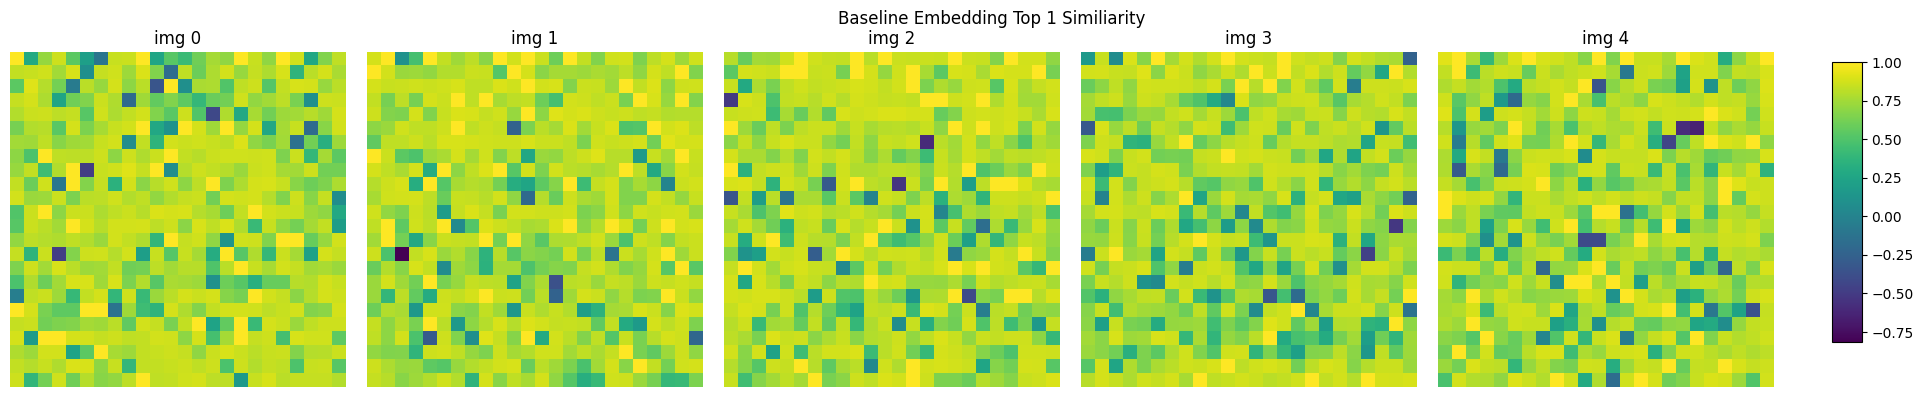

In [26]:
top = 1
plot_feature_per_image(bs_sims_list[:,:,top], f"Baseline Embedding Top {top} Similiarity")

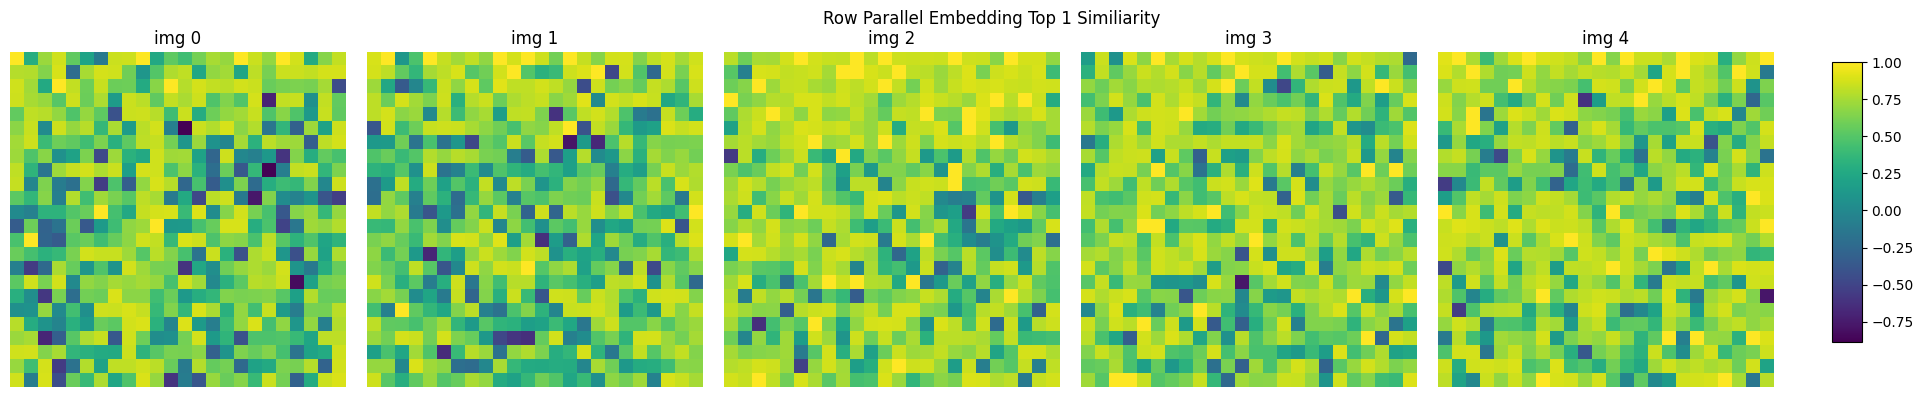

In [27]:
top = 1
plot_feature_per_image(pl_sims_list[:,:,top], f"Row Parallel Embedding Top {top} Similiarity")

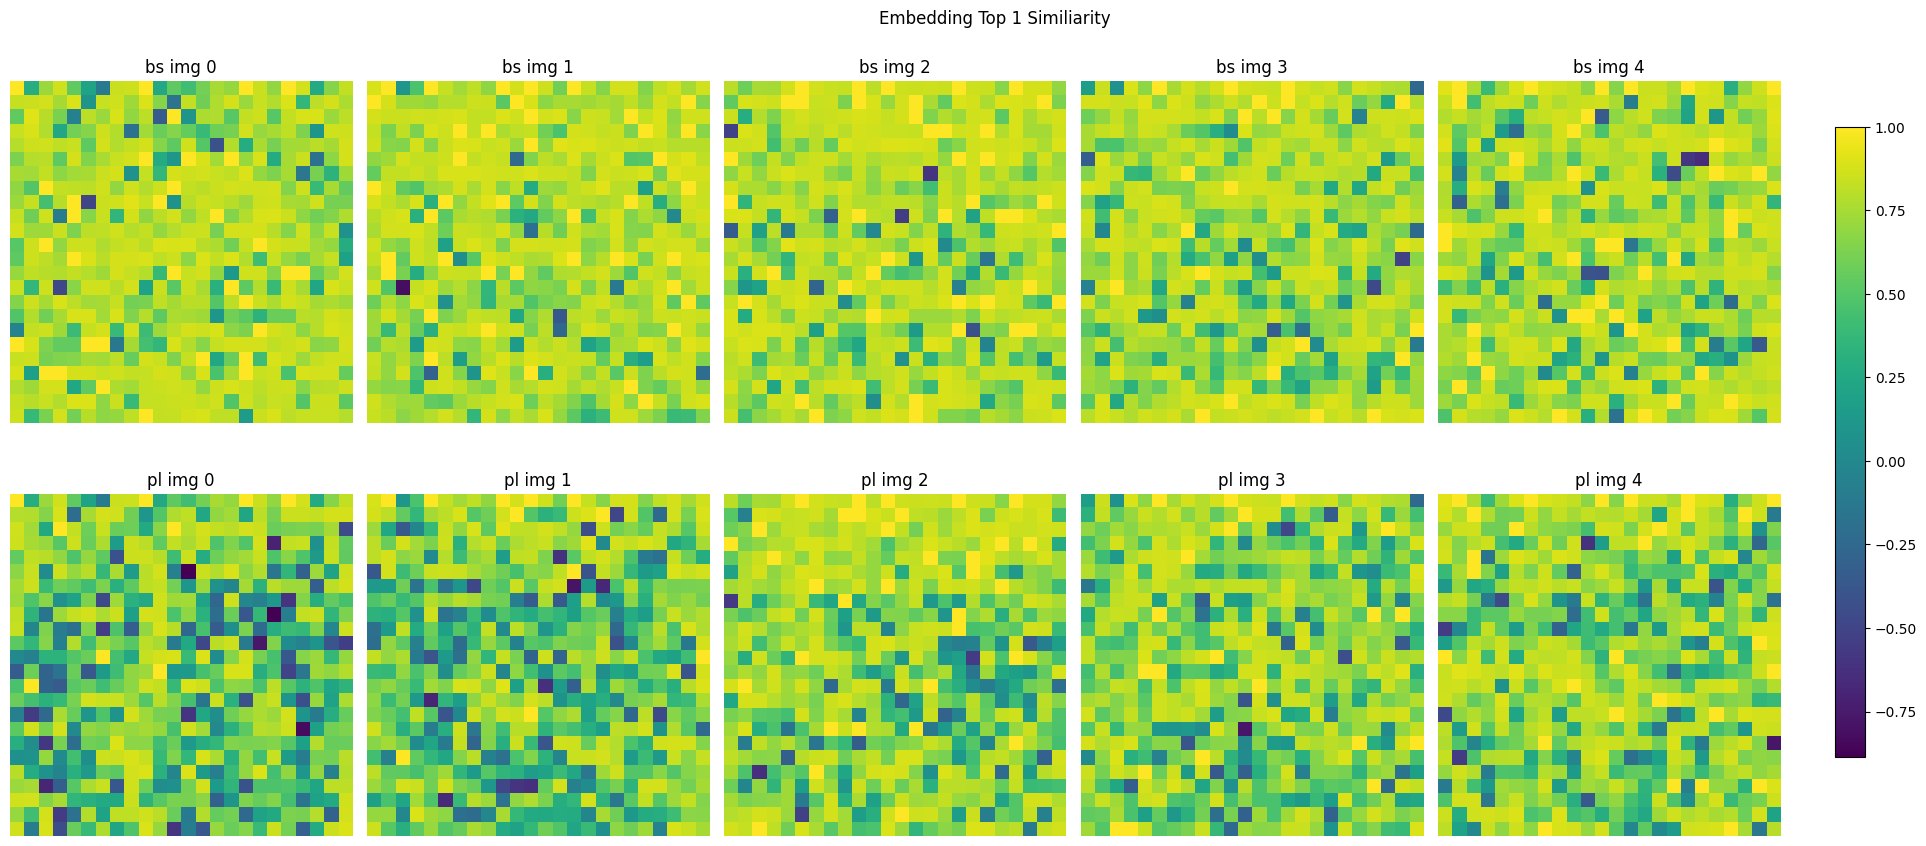

In [28]:
def plot_feature_per_image_two_row(feature1, feature2, title, cmap="viridis"):
    assets_dir = "assets/"
    B, N = feature1.shape
    vmin = min(np.nanmin(feature1), np.nanmin(feature2))
    vmax = max(np.nanmax(feature1), np.nanmax(feature2))
    norm = Normalize(vmin=vmin, vmax=vmax)

    fig, axes = plt.subplots(2, B, figsize=(4 * B, 9))
    
    axs = axes[0]
    for b, ax in enumerate(axs):
        img = feature1[b].reshape(H, W)
        im = ax.imshow(img, cmap=cmap, norm=norm)
        ax.set_title(f"bs img {b}")
        ax.axis("off")

    axs = axes[1]
    for b, ax in enumerate(axs):
        img = feature2[b].reshape(H, W)
        im = ax.imshow(img, cmap=cmap, norm=norm)
        ax.set_title(f"pl img {b}")
        ax.axis("off")

    fig.suptitle(title)
    fig.tight_layout(rect=[0, 0, 0.9, 1])  # 右边预留 10% 宽度

    cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])  # [left, bottom, width, height]
    fig.colorbar(im, cax=cbar_ax)

    plt.show()

top=1
plot_feature_per_image_two_row(bs_sims_list[:,:,top], pl_sims_list[:,:,top], f"Embedding Top {top} Similiarity")

(5, 576)


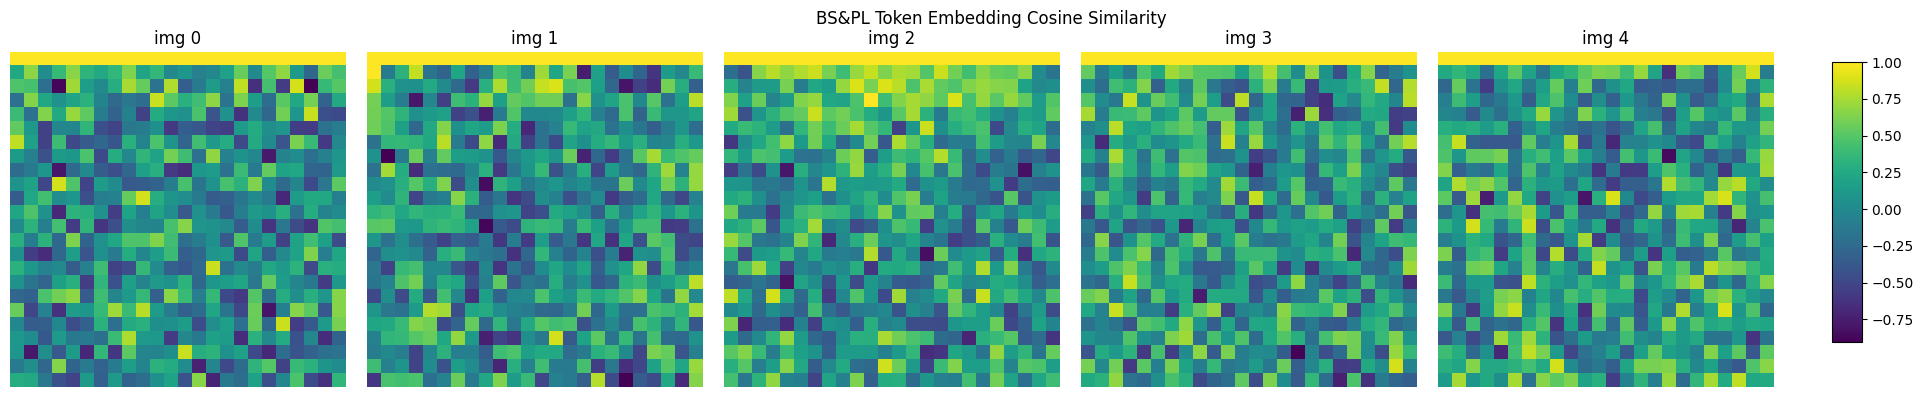

In [29]:
def token_pair_sim(bs_token, pl_token, codebook):

    B, L = bs_token.shape
    sims = np.zeros((B, L), dtype=np.float32)

    for b in range(B):
        for t in range(L):
            bs_id = bs_token[b, t]
            pl_id = pl_token[b, t]
            sims[b, t] = codebook[bs_id] @ codebook[pl_id]

    return sims

bp_token_sim = token_pair_sim(bs_token, pl_token, codebook) 
print(bp_token_sim.shape)
plot_feature_per_image(bp_token_sim, "BS&PL Token Embedding Cosine Similarity")

num used codes: 4174
Mean:  tensor(0.0138)


/tmp/ipykernel_21480/34101267.py:12: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  sub = sub / (np.linalg.norm(sub, axis=1, keepdims=True) + 1e-9)


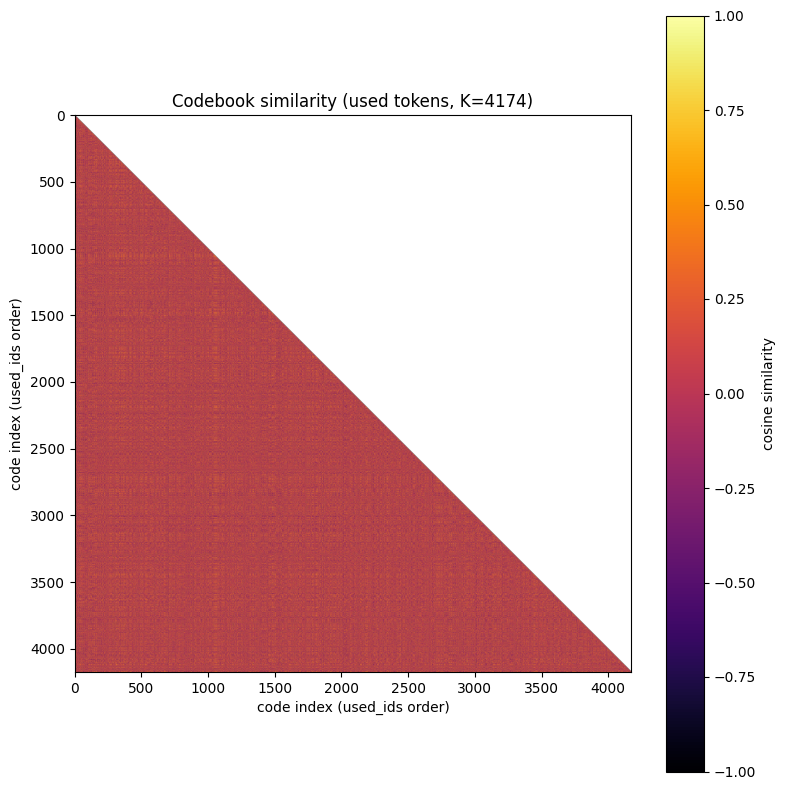

In [30]:
def plot_codebook_sim_used_tokens(codebook, bs_token, pl_token,
                                  save="codebook_sim_used_tokens.png", sim="cos"):

    used_ids = np.unique(
        np.concatenate([bs_token.reshape(-1), pl_token.reshape(-1)], axis=0)
    )
    print("num used codes:", len(used_ids))

    sub = codebook[used_ids]                              # [K, D]

    if sim == "cos":
        sub = sub / (np.linalg.norm(sub, axis=1, keepdims=True) + 1e-9)

        sim = sub @ sub.T
    # elif sim == "l2":
        # sim = 
    print("Mean: ", sim.mean())

    K = sim.shape[0]
    mask = np.triu(np.ones((K, K), dtype=bool), k=1)
    sim_masked = np.ma.array(sim, mask=mask)

    plt.figure(figsize=(8, 8))
    im = plt.imshow(sim_masked, origin="upper", cmap="inferno",
                    vmin=-1.0, vmax=1.0)
    plt.title(f"Codebook similarity (used tokens, K={K})")
    plt.xlabel("code index (used_ids order)")
    plt.ylabel("code index (used_ids order)")
    cbar = plt.colorbar(im)
    cbar.set_label("cosine similarity")

    plt.tight_layout()
    plt.show()
plot_codebook_sim_used_tokens(codebook, bs_token, pl_token)

In [31]:
import numpy as np
import matplotlib.pyplot as plt

def neighbor_sim_map_for_sample(tokens_1d, codebook, H, W, direction="left", sim="cos"):
    # cb = codebook / (np.linalg.norm(codebook, axis=1, keepdims=True) + 1e-9)
    cb = F.normalize(codebook, p=2, dim=-1)
    grid = tokens_1d.reshape(H, W)
    nbr = np.full_like(grid, -1)

    if direction == "left":
        nbr[:, 1:] = grid[:, :-1]
    elif direction == "right":
        nbr[:, :-1] = grid[:, 1:]
    elif direction == "up":
        nbr[1:, :] = grid[:-1, :]
    elif direction == "down":
        nbr[:-1, :] = grid[1:, :]
    else:
        raise ValueError(f"unknown direction: {direction}")

    cur_flat = grid.reshape(-1)
    nbr_flat = nbr.reshape(-1)
    L = cur_flat.shape[0]

    sims_flat = np.full(L, np.nan, dtype=np.float32)
    mask = nbr_flat >= 0

    cur_emb = cb[cur_flat[mask]]           # [M, D]
    nbr_emb = cb[nbr_flat[mask]]           # [M, D]
    if sim == "cos":
        sims_flat[mask] = (cur_emb * nbr_emb).sum(axis=1)
    elif sim == "l2":
        sims_flat[mask] = torch.norm(cur_emb - nbr_emb, dim=1)
    else:
        raise ValueError(f"unknown sim: {sim}")

    sim_map = sims_flat.reshape(H, W)      # [H, W]
    return sim_map


def plot_neighbor_sim_row(codebook, tokens, H, W,
                          direction="left",
                          save_name="neighbor_sim_row.png",
                          cmap="inferno",
                          sim="cos"):
    B, L = tokens.shape
    assert H * W == L, "H * W 必须等于 seqLen"

    fig, axes = plt.subplots(1, B, figsize=(4 * B, 4))
    if B == 1:
        axes = [axes]

    for b, ax in enumerate(axes):
        sim_map = neighbor_sim_map_for_sample(tokens[b], codebook, H, W, direction, sim)
        sim_masked = np.ma.array(sim_map, mask=np.isnan(sim_map))

        im = ax.imshow(sim_masked,
                       origin="upper",
                       cmap=cmap,
                       vmin=-1.0,
                       vmax=1.0)

        ax.set_title(f"sample {b} ({direction}) {sim}")
        ax.set_xticks([])
        ax.set_yticks([])

    cbar = fig.colorbar(im, ax=axes, fraction=0.046, pad=0.04)
    cbar.set_label("Similarity")

    # plt.tight_layout()
    # plt.savefig(save_name, dpi=300)
    # plt.close()
    plt.show()


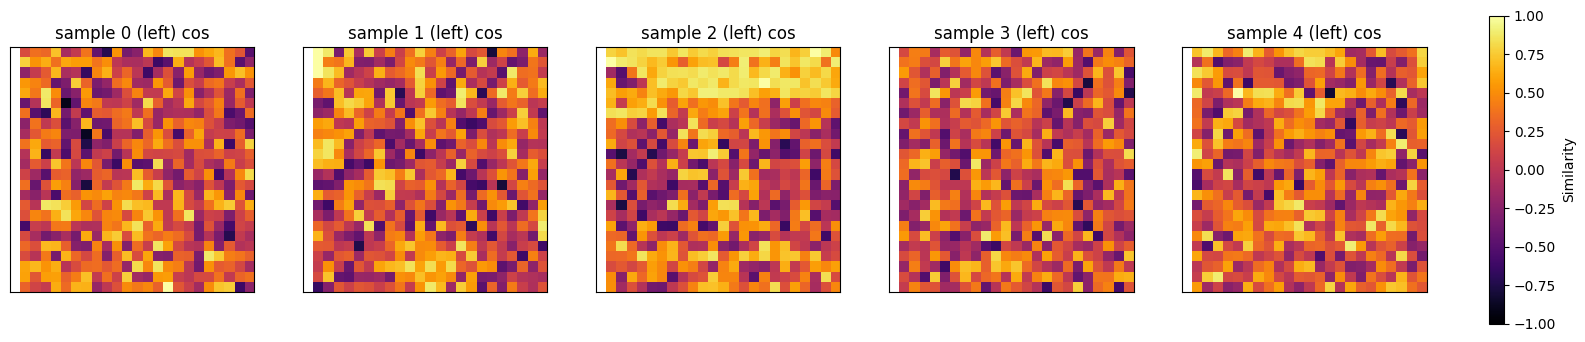

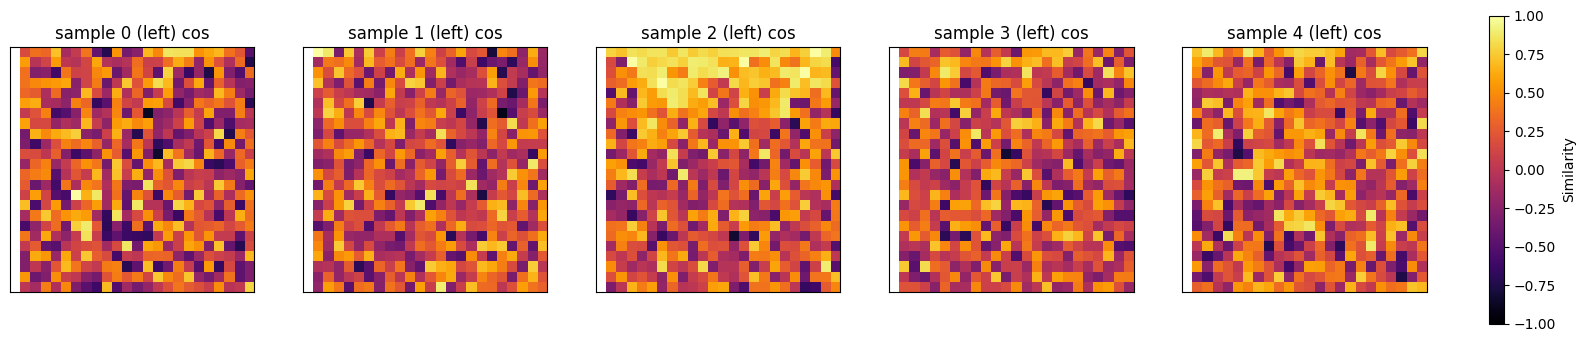

In [32]:
plot_neighbor_sim_row(codebook, bs_token, H, W,
                      direction="left",
                      save_name="bs_neighbor_left_row.png")
plot_neighbor_sim_row(codebook, pl_token, H, W,
                      direction="left",
                      save_name="pl_neighbor_up_row.png")
 

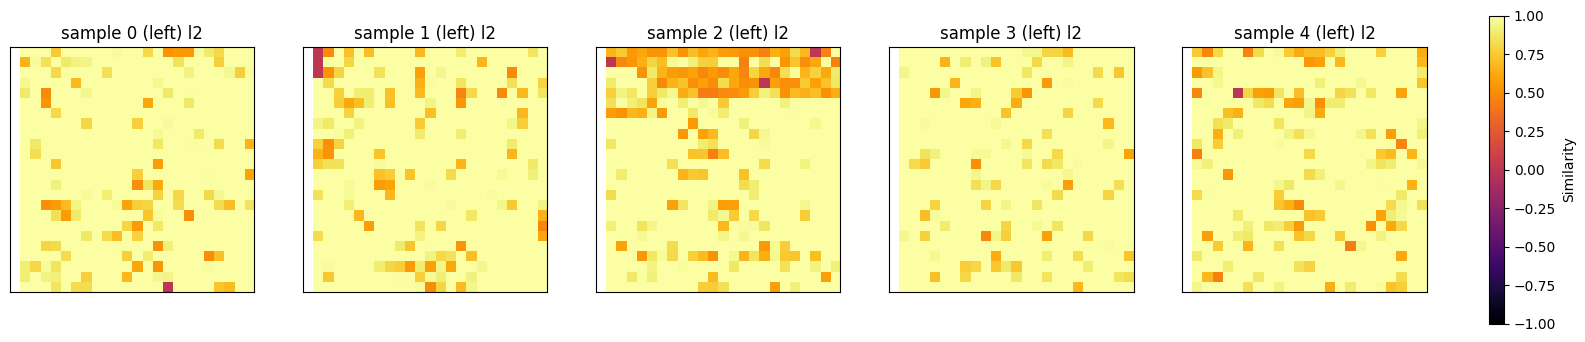

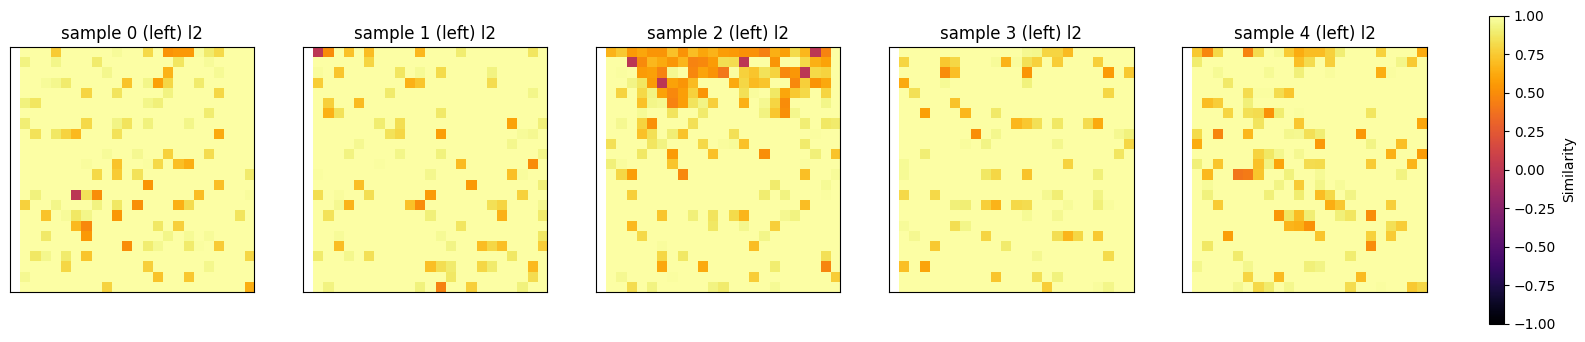

In [33]:
plot_neighbor_sim_row(codebook, bs_token, H, W,
                      direction="left",
                      save_name="bs_neighbor_left_row.png",
                      sim="l2")
plot_neighbor_sim_row(codebook, pl_token, H, W,
                      direction="left",
                      save_name="pl_neighbor_up_row.png",
                      sim="l2")
 

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  # 只为触发 3D 注册

# 1. 准备：归一化 + PCA（只在用到的 code 上拟合）
def prepare_spherical_pca(codebook, bs_token, pl_token, n_components=3):
    # codebook: [V, D] numpy
    cb = codebook / (np.linalg.norm(codebook, axis=1, keepdims=True) + 1e-9)  # 单位球面

    used_ids = np.unique(
        np.concatenate([bs_token.reshape(-1), pl_token.reshape(-1)], axis=0)
    )
    used_emb = cb[used_ids]  # [K, D]

    pca = PCA(n_components=n_components)
    pca.fit(used_emb)

    return cb, pca  # cb 是归一化后的 codebook


# 2. 把高维 unit embedding 投影到 3D 再拉回 3D 球面
def project_to_sphere3d(emb, pca):
    """
    emb: [L, D] numpy, 已经是 unit vector
    返回: [L, 3]，在 3D 单位球上的坐标
    """
    z = pca.transform(emb)          # [L, 3]
    norm = np.linalg.norm(z, axis=1, keepdims=True) + 1e-9
    z_unit = z / norm               # 投到 3D 球面上
    return z_unit


# 3. 画 1×N 的 3D token 轨迹（baseline vs row-parallel）
def plot_token_trajectories_sphere3d(cb_norm, pca,
                                     bs_token, pl_token,
                                     samples=None,
                                     save_name="traj_sphere3d.png",
                                     front=576):
    """
    cb_norm: [V, D] 归一化后的 codebook
    bs_token, pl_token: [B, L]，same shape
    samples: 要画的 sample index 列表，比如 range(5)
    """
    B, L = bs_token.shape
    if samples is None:
        samples = list(range(min(5, B)))
    n = len(samples)

    fig = plt.figure(figsize=(5 * n, 4))
    for i, b in enumerate(samples):
        ax = fig.add_subplot(1, n, i + 1, projection="3d")

        u = np.linspace(0, 2 * np.pi, 60)
        v = np.linspace(0, np.pi, 30)
        xs = np.outer(np.cos(u), np.sin(v))
        ys = np.outer(np.sin(u), np.sin(v))
        zs = np.outer(np.ones_like(u), np.cos(v))
        ax.plot_wireframe(xs, ys, zs,
                          rstride=2, cstride=2,
                          color="lightgray", linewidth=0.4, alpha=0.5)

        ax.set_xlim(-1, 1)
        ax.set_ylim(-1, 1)
        ax.set_zlim(-1, 1)

        bs_ids = bs_token[b]            # [L]
        pl_ids = pl_token[b]            # [L]

        bs_emb = cb_norm[bs_ids]        # [L, D]
        pl_emb = cb_norm[pl_ids]        # [L, D]

        bs_xyz = project_to_sphere3d(bs_emb, pca)   # [L, 3]
        pl_xyz = project_to_sphere3d(pl_emb, pca)   # [L, 3]
        bs_xyz, pl_xyz =  bs_xyz[:front, :], pl_xyz[:front, :]
        # baseline 轨迹
        ax.plot(bs_xyz[:, 0], bs_xyz[:, 1], bs_xyz[:, 2],
                linewidth=1.5, label="baseline", alpha=0.9)
        # row-parallel 轨迹
        ax.plot(pl_xyz[:, 0], pl_xyz[:, 1], pl_xyz[:, 2],
                linewidth=1.2, linestyle="--", label="row-parallel", alpha=0.9)

        # 起点/终点标记（可选）
        ax.scatter(bs_xyz[0, 0], bs_xyz[0, 1], bs_xyz[0, 2], s=25)
        ax.scatter(bs_xyz[-1, 0], bs_xyz[-1, 1], bs_xyz[-1, 2], s=25)

        ax.set_title(f"sample {b}")
        ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
        ax.set_box_aspect([1, 1, 1])

        if i == 0:
            ax.legend(loc="upper left", fontsize=8)

    plt.tight_layout()
    # plt.savefig(save_name, dpi=300)
    # plt.close()
    plt.show()

/tmp/ipykernel_21480/2480675022.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  cb = codebook / (np.linalg.norm(codebook, axis=1, keepdims=True) + 1e-9)  # 单位球面


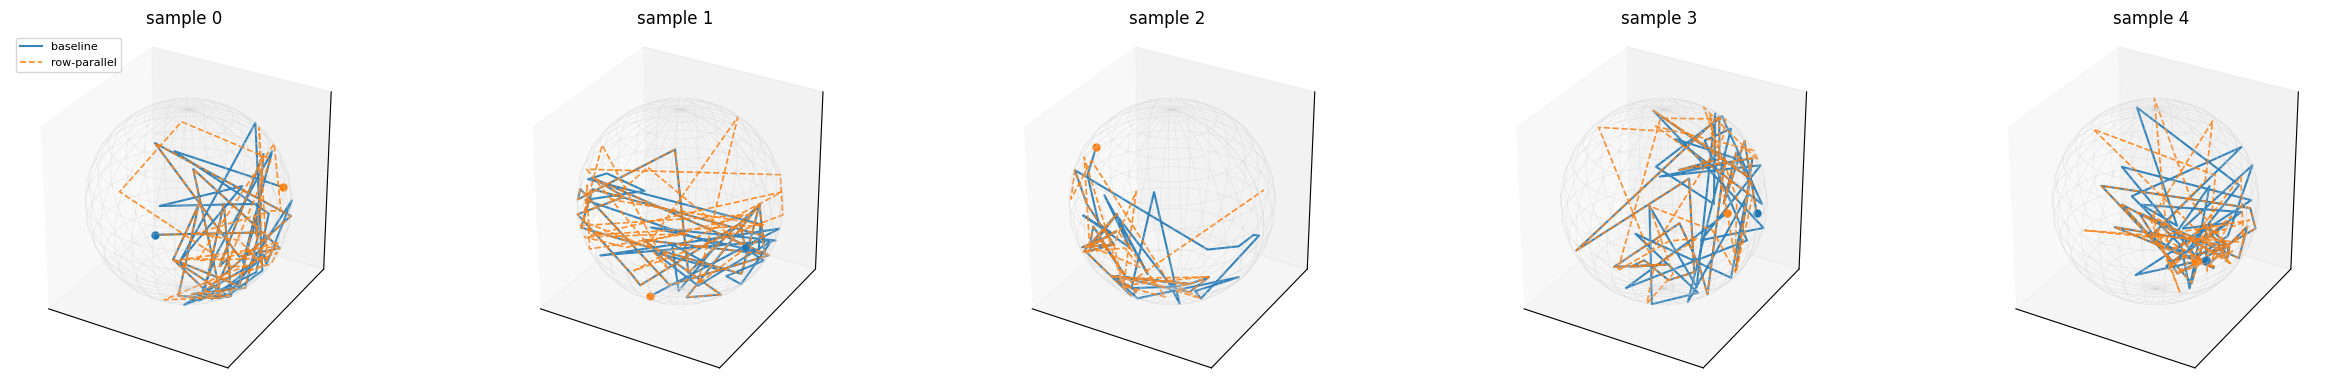

In [37]:
cb_norm, pca = prepare_spherical_pca(codebook, bs_token, pl_token)

plot_token_trajectories_sphere3d(
    cb_norm,
    pca,
    bs_token,
    pl_token,
    samples=range(5),  # 画前 5 个 pic
    save_name="layer22_token_traj_sphere3d.png",
    front=48
)
